
 Dataset Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7385 entries, 0 to 7384
Data columns (total 12 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Make                              7385 non-null   object 
 1   Model                             7385 non-null   object 
 2   Vehicle Class                     7385 non-null   object 
 3   Engine Size(L)                    7385 non-null   float64
 4   Cylinders                         7385 non-null   int64  
 5   Transmission                      7385 non-null   object 
 6   Fuel Type                         7385 non-null   object 
 7   Fuel Consumption City (L/100 km)  7385 non-null   float64
 8   Fuel Consumption Hwy (L/100 km)   7385 non-null   float64
 9   Fuel Consumption Comb (L/100 km)  7385 non-null   float64
 10  Fuel Consumption Comb (mpg)       7385 non-null   int64  
 11  CO2 Emissions(g/km)               7385 non-null   in

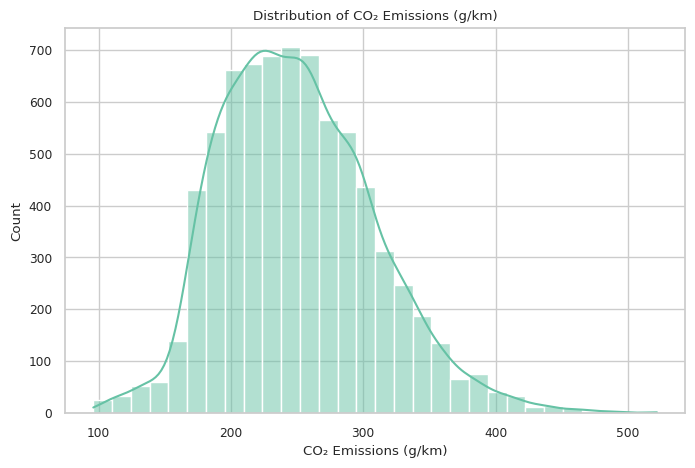

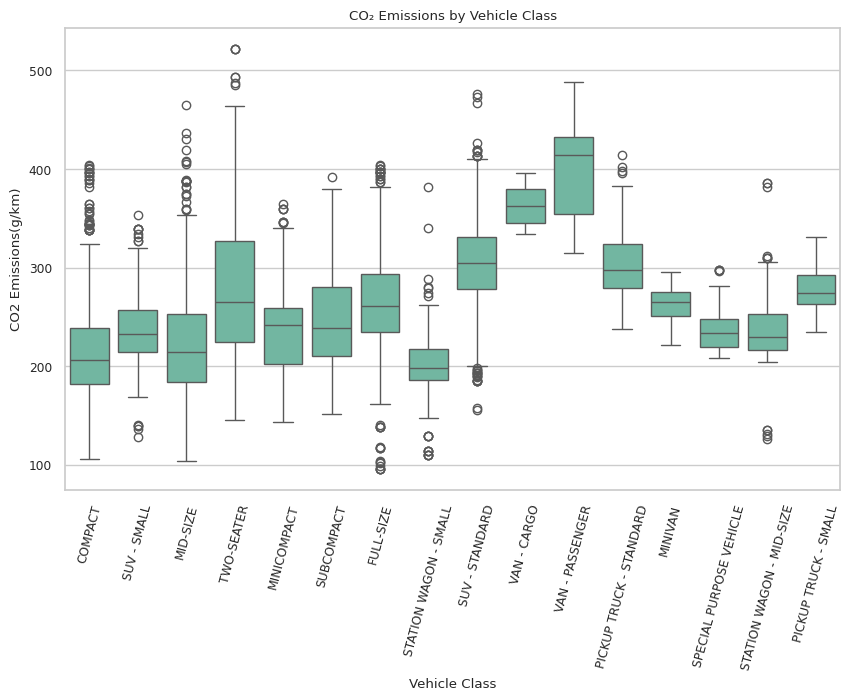

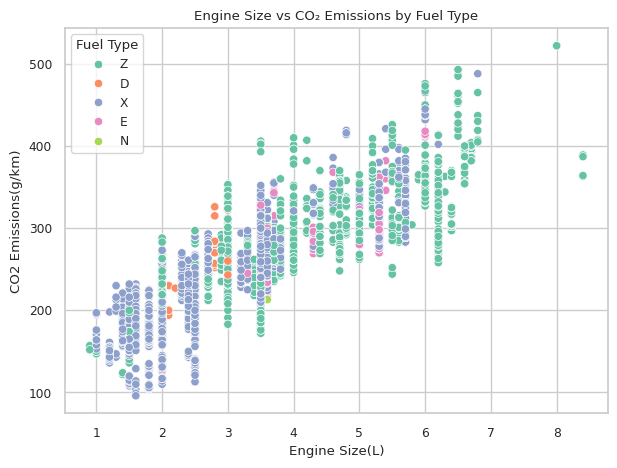

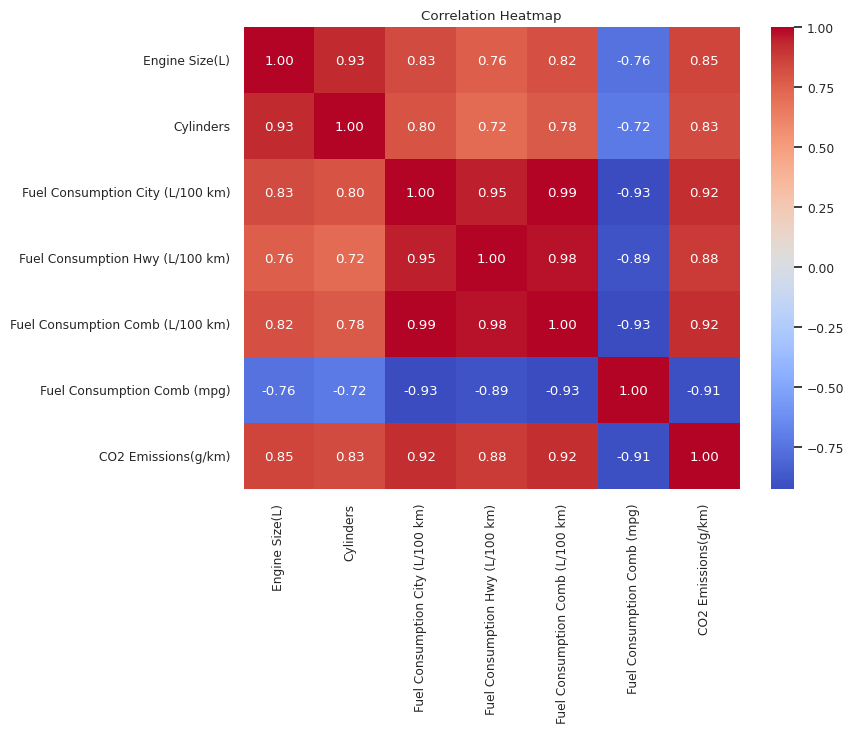

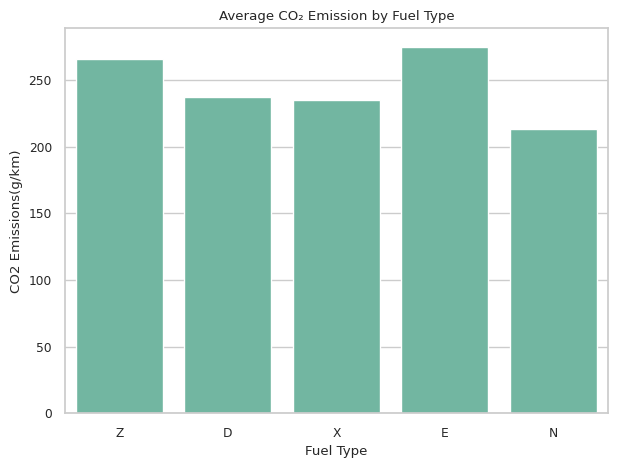

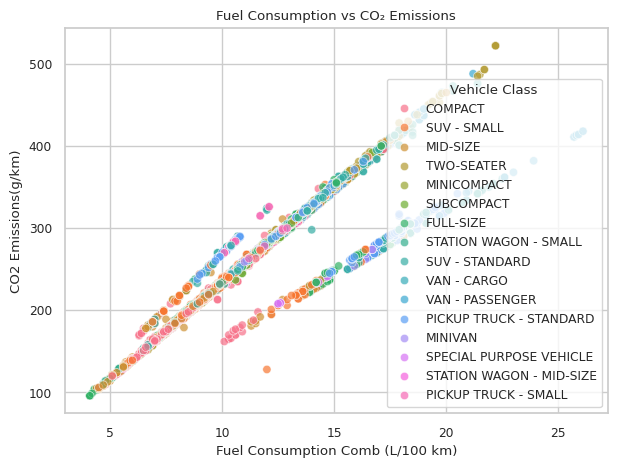

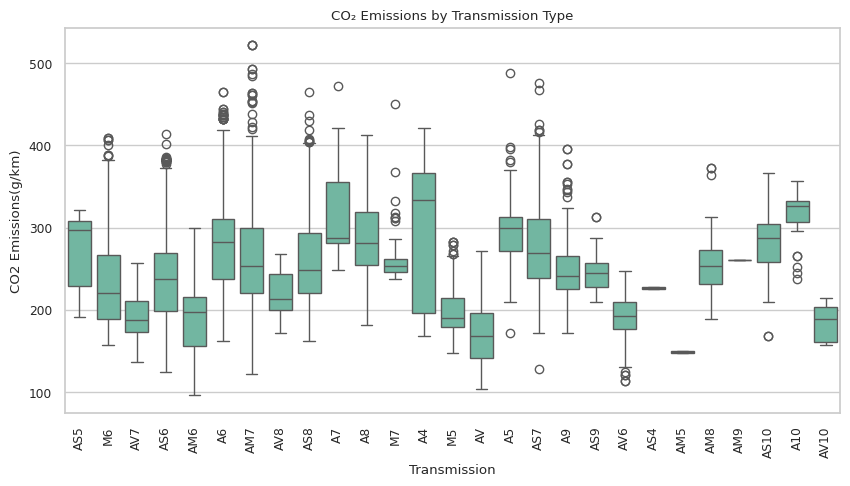

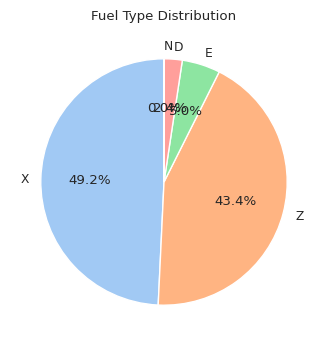

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("co2.csv")
print("\n Dataset Info:\n")
print(df.info())

print("\n Summary Statistics:\n")
print(df.describe(include='all').transpose())

#missing values
print("\n Missing Values:\n")
print(df.isnull().sum())

#  Unique values (column) 
print("\n Unique Values per Column:\n")
for col in df.columns:
    print(f"{col}: {df[col].nunique()}")

# Plot settings 
sns.set(style="whitegrid", palette="Set2", font_scale=0.8)

# Distribution of CO2 Emissions
plt.figure(figsize=(8,5))
sns.histplot(df['CO2 Emissions(g/km)'], bins=30, kde=True)
plt.title("Distribution of CO₂ Emissions (g/km)")
plt.xlabel("CO₂ Emissions (g/km)")
plt.ylabel("Count")
plt.show()

#  CO₂ Emissions by Vehicle Class 
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Vehicle Class', y='CO2 Emissions(g/km)')
plt.title("CO₂ Emissions by Vehicle Class")
plt.xticks(rotation=75)
plt.show()

#  Engine Size vs CO₂ Emissions 
plt.figure(figsize=(7,5))
sns.scatterplot(data=df, x='Engine Size(L)', y='CO2 Emissions(g/km)', hue='Fuel Type')
plt.title("Engine Size vs CO₂ Emissions by Fuel Type")
plt.show()

#  Correlation Heatmap for Numeric Columns 
plt.figure(figsize=(8,6))
sns.heatmap(df.select_dtypes(include=[np.number]).corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

# Average CO₂ Emission by Fuel Type 
plt.figure(figsize=(7,5))
sns.barplot(data=df, x='Fuel Type', y='CO2 Emissions(g/km)', estimator=np.mean, errorbar=None)
plt.title("Average CO₂ Emission by Fuel Type")
plt.show()

#  Fuel Consumption vs CO₂ Emissions 
plt.figure(figsize=(7,5))
sns.scatterplot(data=df, x='Fuel Consumption Comb (L/100 km)', y='CO2 Emissions(g/km)', hue='Vehicle Class', alpha=0.7)
plt.title("Fuel Consumption vs CO₂ Emissions")
plt.show()

# Transmission Type vs CO₂ Emissions 
plt.figure(figsize=(10,5))
sns.boxplot(data=df, x='Transmission', y='CO2 Emissions(g/km)')
plt.title("CO₂ Emissions by Transmission Type")
plt.xticks(rotation=90)
plt.show()

# Fuel Type Distribution
plt.figure(figsize=(6,4))
df['Fuel Type'].value_counts().plot(kind='pie', autopct='%1.1f%%', startangle=90, colors=sns.color_palette("pastel"))
plt.title("Fuel Type Distribution")
plt.ylabel("")
plt.show()
